1.2 Постройте столбчатый график длительности заправки на каждой сети АЗС по наилучшей оценке — медиане, упорядочив сети по возрастанию времени. 

Задайте размер графика 10 на 5 дюймов.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
data = pd.read_csv("./visits.csv", sep="\t")

In [3]:
data['date_time'] = pd.to_datetime(data['date_time'], format='%Y%m%dT%H%M%S') + pd.Timedelta(hours=3)

In [4]:
data['local_time'] = (pd.to_datetime(data['date_time'], format='%Y-%m-%dT%H:%M:%S')
    + pd.Timedelta(hours=3))

In [5]:
data['date_hour'] = data['local_time'].dt.round('1H')
data['too_fast'] = data['time_spent'] < 60
data['too_slow'] = data['time_spent'] > 1000

C:\Users\yuliy\AppData\Local\Temp\ipykernel_1956\1205334671.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data['date_hour'] = data['local_time'].dt.round('1H')


In [6]:
too_fast_stat = data.pivot_table(index='id', values='too_fast')
good_ids = too_fast_stat.query('too_fast < 0.5')
good_data = data.query('id in @good_ids.index')
good_data = good_data.query('60 <= time_spent <= 1000')

In [7]:
station_stat = data.pivot_table(index="id", values="time_spent", aggfunc="median")
good_station_stat = good_data.pivot_table(index="id", values="time_spent", aggfunc="median")

stat = data.pivot_table(index='name', values='time_spent')
good_stat = good_data.pivot_table(index='name', values='time_spent', aggfunc='median')
stat['good_time_spent'] = good_stat['time_spent']

name_stat = data.pivot_table(index='name', values='time_spent')
good_name_stat = good_data.pivot_table(index='name', values='time_spent', aggfunc='median')
name_stat['good_time_spent'] = good_name_stat['time_spent']

id_name = good_data.pivot_table(index='id', values='name', aggfunc=['first', 'count'])
id_name.columns = ['name', 'count']
station_stat_full = id_name.join(good_station_stat)

good_stat2 = (station_stat_full.query('count > 30').pivot_table(index='name', values='time_spent', aggfunc=['median', 'count']))
good_stat2.columns = ['median_time', 'stations']
final_stat = stat.join(good_stat2)

<Axes: xlabel='name'>

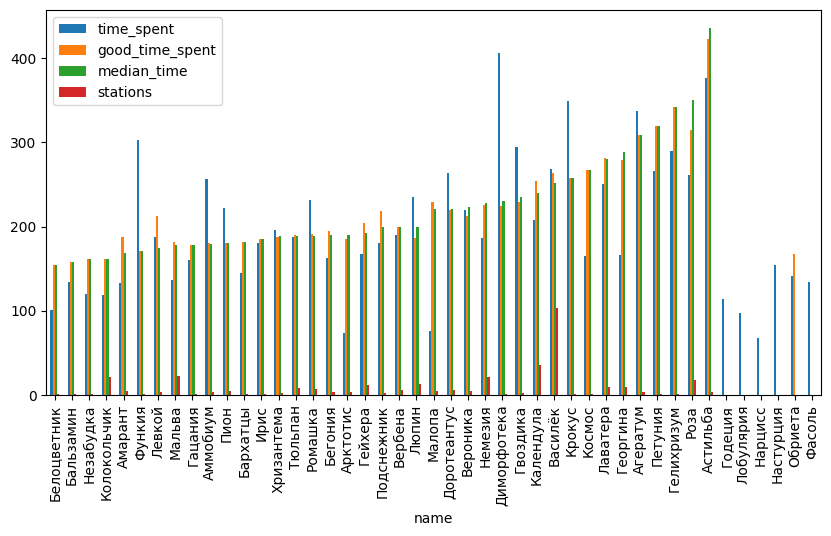

In [8]:
final_stat.sort_values(by='median_time').plot(kind='bar', figsize=(10,5))

1.2 Постройте столбчатый график медианной продолжительности заправки на каждой сети, упорядочив их по возрастанию времени. 

Пустые значения отбросьте методом dropna(). Задайте размер графика 10 на 5 дюймов. Добавьте линии сетки. 

Всё это сделайте в одно действие, не меняя переменную final_stat.

<Axes: xlabel='name'>

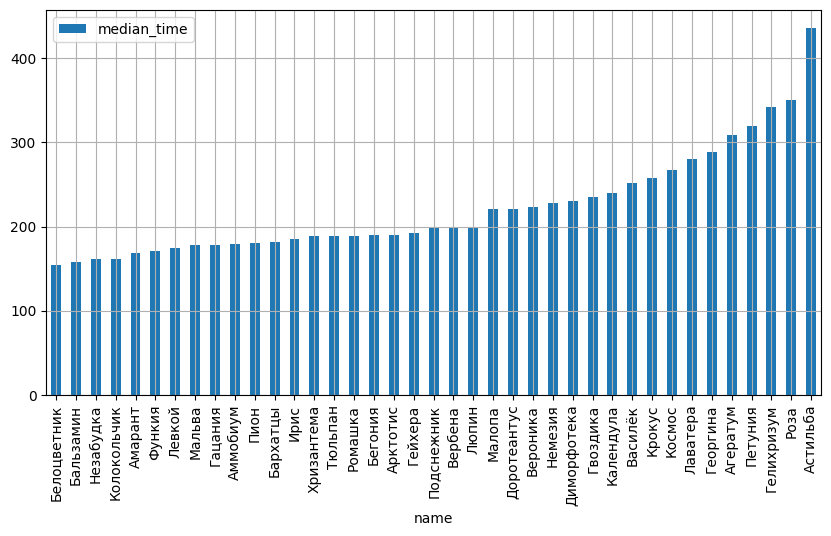

In [10]:
final_stat.dropna(subset=['median_time']).sort_values(by='median_time').plot(y='median_time', kind='bar', figsize=(10,5), grid=True)

1.3 Выявите самые крупные сети — постройте гистограмму числа АЗС внутри сетей. Поделите значения на 100 корзин. 

Все необходимые данные в таблице final_stat.

In [12]:
final_stat.head().reset_index()

,name,time_spent,good_time_spent,median_time,stations
0,Агератум,337.802721,309.0,308.50,3.0
1,Амарант,132.760012,187.5,169.00,5.0
2,Аммобиум,256.708042,180.5,178.75,4.0
3,Арктотис,73.879984,185.0,190.50,3.0
4,Астильба,376.143149,423.0,435.50,4.0


array([[<Axes: title={'center': 'stations'}>]], dtype=object)

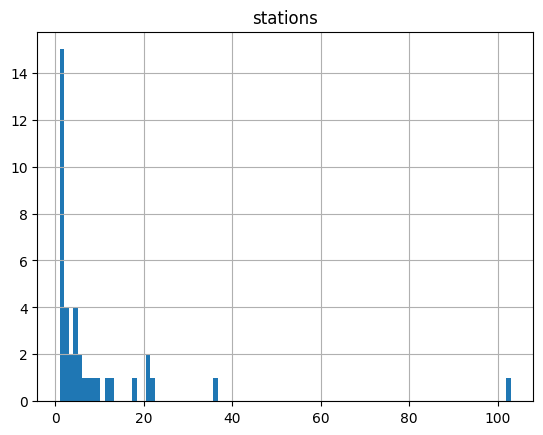

In [14]:
final_stat.hist('stations', bins=100)

1.4 Выберите из final_stat сети, в которых более 10 АЗС. Результат сохраните в таблице big_nets_stat. Выведите её на экран.

In [16]:
big_nets_stat = final_stat.query('stations > 10')
big_nets_stat.reset_index()

,name,time_spent,good_time_spent,median_time,stations
0,Василёк,268.849897,264.0,252.00,103.0
1,Гейхера,167.445947,204.0,192.00,12.0
2,Календула,207.357323,254.0,240.00,36.0
3,Колокольчик,119.131564,161.0,161.00,21.0
4,Люпин,235.440937,186.0,200.00,13.0
5,Мальва,136.562234,182.0,177.75,22.0
6,Немезия,186.535207,226.0,227.50,21.0
7,Роза,260.877217,315.0,350.00,18.0


1.5 Создайте в station_stat_full новый столбец 'group_name', где для сетей АЗС из big_nets_stat названия останутся прежними, 

а имена остальных измените на 'Другие'. Распечатайте первые 5 строк station_stat_full.

In [17]:
station_stat_full['group_name'] = station_stat_full['name'].where(station_stat_full['name'].isin(big_nets_stat.index),'Другие')
station_stat_full.head()

,name,count,time_spent,group_name
id,,,,
00ca1b70,Вероника,131,166.0,Другие
0178ce70,Василёк,164,234.5,Василёк
01abf4e9,Гацания,30,181.5,Другие
030a9067,Колокольчик,228,135.5,Колокольчик
03740f2d,Василёк,157,289.0,Василёк


1.6 Соберите таблицу с потенциальными ключевыми партнёрами. Повторите знакомые вычисления, на этот раз группируя АЗС не по name, а по group_name.

Создайте переменную stat_grouped. Сперва сделайте срез по station_stat_full: 

выберите только те АЗС, на которых было более 30 заправок. 

Затем по этой выборке постройте сводную таблицу расчёта медианной продолжительности заправки: 

сгруппируйте по 'group_name', значением укажите 'time_spent', параметру aggfunc передайте список функций 'median' и 'count'.

Дайте имена 'time_spent' и 'count' новоиспечённым столбцам в stat_grouped.

Отсортируйте stat_grouped по возрастанию значений столбца 'time_spent'. Укажите параметр, необходимый для сохранения результатов сортировки в stat_grouped.

Распечатайте значения stat_grouped.

In [18]:
stat_grouped = station_stat_full.query(
    'count > 30').pivot_table(index='group_name', values='time_spent', aggfunc=['median', 'count'])

In [20]:
stat_grouped.columns = ['time_spent', 'count']

In [22]:
stat_grouped.sort_values(by='time_spent', inplace=True)
stat_grouped

,time_spent,count
group_name,,
Колокольчик,161.00,21
Мальва,177.75,22
Гейхера,192.00,12
Люпин,200.00,13
Другие,208.75,104
Немезия,227.50,21
Календула,240.00,36
Василёк,252.00,103
Роза,350.00,18


1.7 Постройте круговую диаграмму с числом АЗС в каждой сети. Задайте ей размер 8x8 дюймов.

<Axes: ylabel='count'>

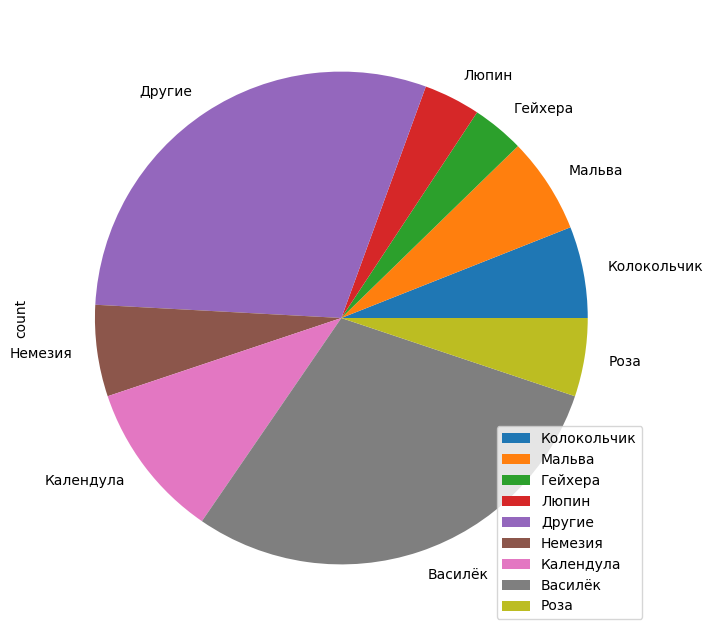

In [25]:
stat_grouped.plot(y='count', kind='pie', figsize=(8,8))

2.1 Создайте в good_data новый столбец 'group_name', где сетям из big_nets_stat оставьте их оригинальные имена, 

а остальные сети переименуйте на 'Другие'. Распечатайте первые 5 строк good_data.

In [27]:
good_data['group_name'] = good_data['name'].where(good_data['name'].isin(good_data),'Другие')
good_data.head()

,date_time,id,time_spent,name,local_time,date_hour,too_fast,too_slow,group_name
0,2018-04-06 19:53:58,76144fb2,98.0,Василёк,2018-04-06 22:53:58,2018-04-06 23:00:00,False,False,Другие
2,2018-04-03 20:28:24,76144fb2,220.0,Василёк,2018-04-03 23:28:24,2018-04-03 23:00:00,False,False,Другие
6,2018-04-02 11:23:21,76144fb2,555.0,Василёк,2018-04-02 14:23:21,2018-04-02 14:00:00,False,False,Другие
7,2018-04-07 03:34:08,76144fb2,286.0,Василёк,2018-04-07 06:34:08,2018-04-07 07:00:00,False,False,Другие
9,2018-04-05 16:19:39,76144fb2,248.0,Василёк,2018-04-05 19:19:39,2018-04-05 19:00:00,False,False,Другие


2.2 Методом hist() постройте гистограмму продолжительности заправки для каждой сети отдельно (напомним, что все небольшие АЗС в общей группе "Другие"). 

Возьмите данные из good_data. Гистограмму разбейте на 50 корзин.

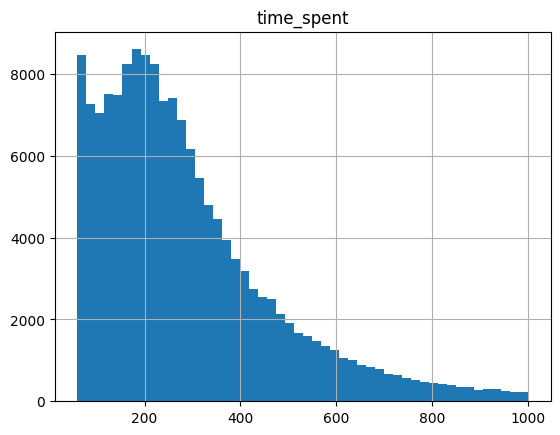

In [29]:
for name, group_data in good_data.groupby('group_name'):
    group_data.hist('time_spent', bins=50)


2.3 Методом plot() c параметром kind='hist' постройте гистограмму продолжительности заправки для каждой сети отдельно 

(напомним, что все малые АЗС — в общей группе "Другие"). Возьмите данные из good_data. 

Столбец, по значениям которого гистограмму следует построить, передайте параметру y, а переменную с названиями графиков параметру title. Гистограмму разбейте на 50 корзин.

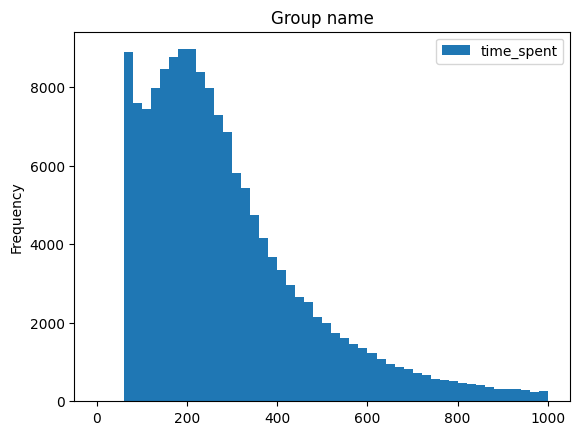

In [30]:
for name, group_data in good_data.groupby('group_name'):
    group_data.plot('group_name', kind='hist', title='Group name', bins=50)